# BloqueA_ML

## Librerías y carga de datos

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, recall_score, f1_score, precision_score, cohen_kappa_score
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier, VotingClassifier

In [10]:
# Cargar los datos
Train = pd.read_csv('../Datos/Train_clean.csv')
Test = pd.read_csv('../Datos/Test_clean.csv')

X_train = Train.drop(columns=['diagnostic','diagnostic_binario']).copy()
y_train = Train['diagnostic'].copy()

X_test = Test.drop(columns=['diagnostic','diagnostic_binario']).copy()
y_test = Test['diagnostic'].copy()

display(X_train.head())

,patient_id,lesion_id,age,fitspatrick,diameter_1,diameter_2,patient_lesion_id,img_id,smoke_False,smoke_True,...,changed_TRUE,changed_UNK,bleed_FALSE,bleed_TRUE,bleed_UNK,elevation_FALSE,elevation_TRUE,elevation_UNK,biopsed_False,biopsed_True
0,PAT_528,992,75,2.0,10.0,8.0,PAT_528_992,PAT_528_992_124.png,1,0,...,0,0,1,0,0,1,0,0,0,1
1,PAT_321,682,85,2.0,7.0,7.0,PAT_321_682,PAT_321_682_236.png,1,0,...,0,0,1,0,0,0,1,0,0,1
2,PAT_684,1302,79,1.0,5.0,5.0,PAT_684_1302,PAT_684_1302_588.png,1,0,...,0,0,0,1,0,0,1,0,0,1
3,PAT_100,393,14,1.0,7.0,3.0,PAT_100_393,"PAT_100_393_595.png, PAT_100_393_898.png",1,0,...,0,0,1,0,0,1,0,0,0,1
4,PAT_629,1192,65,2.0,15.0,13.0,PAT_629_1192,PAT_629_1192_362.png,0,1,...,0,1,0,1,0,0,1,0,0,1


Quedarnos solo con lo necesario

In [11]:
columnas_eliminar = ['patient_id', 'lesion_id', 'patient_lesion_id','img_id']

for col in columnas_eliminar:
    if col in X_train.columns:
        X_train = X_train.drop(columns=[col])
    if col in X_test.columns:
        X_test = X_test.drop(columns=[col])

## Busqueda de hiperparámetros

Para el ajuste de los hiperparámetros de los modelos, se aplica un 5-Fold. Este proceso permite evaluar el rendimiento de forma iterativa, asegurando que los hiperparámetros seleccionados no dependan de una división aleatoria favorable de los datos.

In [12]:
target_names = ['ACK', 'BCC', 'MEL', 'NEV', 'SCC', 'SEK']
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

Difinimos las funciones que vamos a utilizar: `plot_grid_results` y `evaluate_models`

In [13]:
def plot_grid_results(grid, title):
    results = pd.DataFrame(grid.cv_results_)
    
    # 1. Identificar parámetros
    param_cols = [col for col in results.columns if col.startswith('param_')]
    x_param = max(param_cols, key=lambda c: results[c].nunique())
    hue_params = [p for p in param_cols if p != x_param]
    
    plt.figure(figsize=(11, 6))
    
    # 2. Agrupar y Graficar
    # Ordenamos los grupos para que Minkowski no tape siempre a Euclidean
    groups = list(results.groupby(hue_params))
    
    for i, (keys, group) in enumerate(groups):
        group = group.sort_values(x_param)
        label = " | ".join([f"{p.split('__')[-1]}: {v}" for p, v in zip(hue_params, [keys] if len(hue_params)==1 else keys)])
        
        # SOLUCIÓN AL SOLAPAMIENTO: 
        # Usamos grosores diferentes (linewidth) y estilos de línea (linestyle)
        lw = 4 if "euclidean" in str(keys) else 1.5
        ls = '--' if "minkowski" in str(keys) else '-'
        
        plt.plot(group[x_param].astype(str), 
                 group['mean_test_score'], 
                 marker='o', 
                 label=label, 
                 linewidth=lw, 
                 linestyle=ls, 
                 alpha=0.8)

    # 3. Resaltar el mejor punto global
    best_score = grid.best_score_
    best_x = str(grid.best_params_[x_param.replace('param_', '')])
    plt.axhline(y=best_score, color='r', linestyle=':', alpha=0.5)
    plt.annotate(f'Mejor: {best_score:.4f}', 
                 xy=(best_x, best_score), 
                 xytext=(8, 8), textcoords='offset points',
                 arrowprops=dict(arrowstyle='->', color='black'))

    plt.title(f'Optimización de Hiperparámetros: {title}')
    plt.xlabel(x_param.split('__')[-1])
    plt.ylabel('F1-Macro (CV)')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
    plt.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()

def evaluate_models(model_dict, X_test, y_test, target_names):
    """
    Genera un informe completo: Tabla de métricas, Matrices de Confusión y 
    Reportes de Clasificación para cada modelo en el diccionario.
    """
    n_models = len(model_dict)
    global_metrics = []
    
    # 1. Configuración de Subplots para Matrices de Confusión
    fig, axes = plt.subplots(1, n_models, figsize=(4 * n_models, 4))
    if n_models == 1: axes = [axes]

    for i, (name, obj) in enumerate(model_dict.items()):
        # Extraer el modelo (maneja GridSearchCV o modelos directos como Voting)
        model = obj.best_estimator_ if hasattr(obj, 'best_estimator_') else obj
        y_pred = model.predict(X_test)
        
        # --- Cálculo de Métricas Globales ---
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
        rec = recall_score(y_test, y_pred, average='macro', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
        kappa = cohen_kappa_score(y_test, y_pred)
        
        global_metrics.append({
            "Modelo": name,
            "Accuracy": round(acc, 4),
            "Precision (Macro)": round(prec, 4),
            "Recall (Macro)": round(rec, 4),
            "F1-Score (Macro)": round(f1, 4),
            "Kappa": round(kappa, 4)
        })

        # --- Matriz de Confusión ---
        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False,
                    xticklabels=target_names, yticklabels=target_names)
        axes[i].set_title(f'Confusión: {name}')
        axes[i].set_xlabel('Predicho')
        axes[i].set_ylabel('Real')

    plt.tight_layout()
    plt.show()

    # 2. Creación de la Tabla Global Comparativa
    df_global = pd.DataFrame(global_metrics)
    
    # Ordenamos por F1-Score para ver quién es el mejor arriba
    df_global = df_global.sort_values(by="F1-Score (Macro)", ascending=False).reset_index(drop=True)
    
    print("\n--- TABLA COMPARATIVA DE MÉTRICAS GLOBALES ---")
    return df_global

### 1- Modelos simples

#### 1.1 KNN

--- Mejores Hiperparámetros Encontrados ---
knn__metric: manhattan
knn__n_neighbors: 21
knn__weights: distance
Mejor Score (F1-Macro) en CV: 0.5637


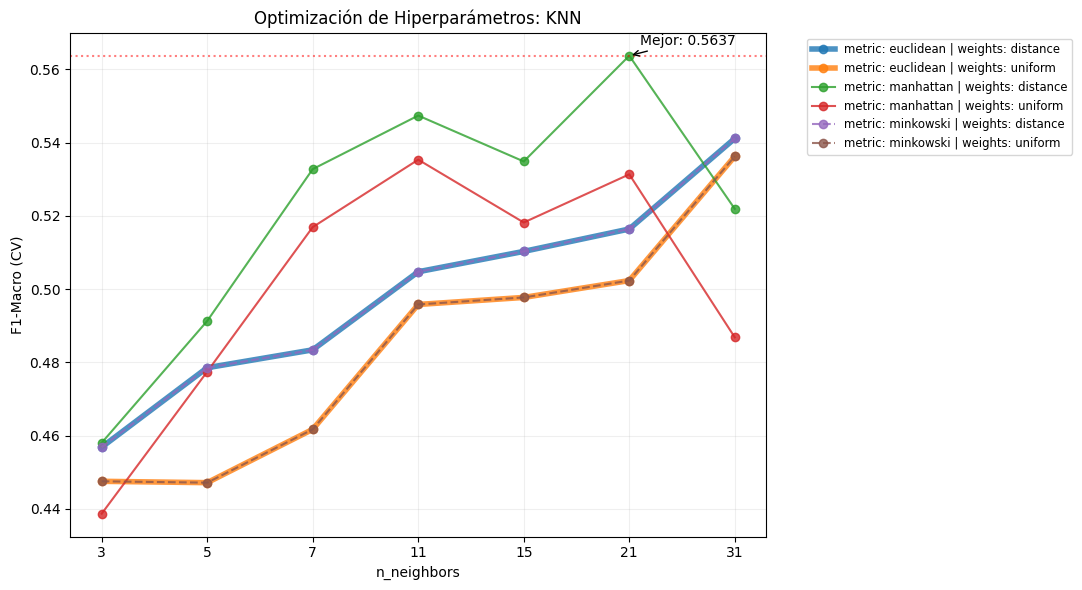

In [14]:
# Se define el pipeline para aplicarlo a cada fold y así evitar data leakage 
# El pipeline calcula la media y desviación solo con los 4 folds de entrenamiento y aplica esa transformación al fold de validación
knn_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

# Diccionario de parámetros extendido
param_grid_knn = {
    'knn__n_neighbors': [3, 5, 7, 11, 15, 21, 31],
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan', 'minkowski']
}

grid_knn = GridSearchCV(knn_pipe,param_grid_knn,cv=cv,scoring='f1_macro',n_jobs=-1)
grid_knn.fit(X_train, y_train) 

print("--- Mejores Hiperparámetros Encontrados ---")
for param, value in grid_knn.best_params_.items():
    print(f"{param}: {value}")

print(f"Mejor Score (F1-Macro) en CV: {grid_knn.best_score_:.4f}")

# Visualización
plot_grid_results(grid_knn,'KNN')

#### 1.2 Regresión Logistica

--- Mejores Hiperparámetros Encontrados ---
rl__C: 0.1
rl__l1_ratio: 0.5
rl__penalty: elasticnet
rl__solver: saga
Mejor Score (F1-Macro) en CV: 0.6301


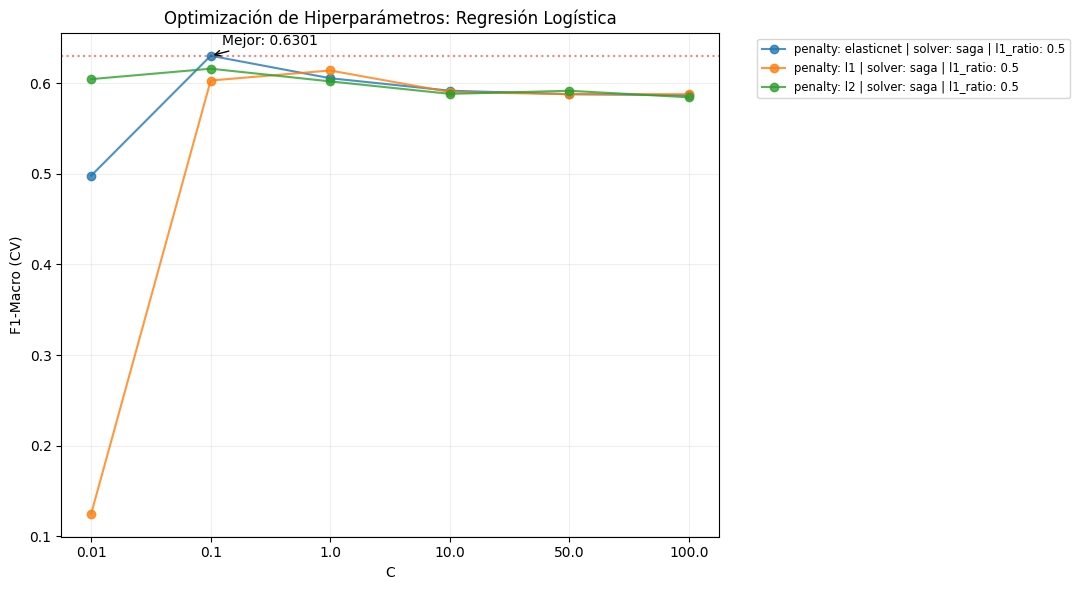

In [15]:
# Definimos el Pipeline
rl_pipe = Pipeline([
    ('scaler', StandardScaler()), 
    ('rl', LogisticRegression(class_weight='balanced', max_iter=2000))
])

# Param_grid optimizado (sin liblinear para evitar el warning)
param_grid_rl = [
    {
        'rl__solver': ['lbfgs'],
        'rl__penalty': ['l2', None], # lbfgs soporta l2 o ninguna penalización
        'rl__C': [0.01, 0.1, 1, 10, 50, 100]
    },
    {
        'rl__solver': ['saga'],
        'rl__penalty': ['l1', 'l2', 'elasticnet'], # saga es el más versátil
        'rl__C': [0.01, 0.1, 1, 10, 50, 100],
        'rl__l1_ratio': [0.5] # Requerido solo si usas elasticnet
    }
]

grid_rl = GridSearchCV(rl_pipe, param_grid_rl, cv=cv, scoring='f1_macro', n_jobs=-1, error_score=0)
grid_rl.fit(X_train, y_train)

print("--- Mejores Hiperparámetros Encontrados ---")
for param, value in grid_rl.best_params_.items():
    print(f"{param}: {value}")

print(f"Mejor Score (F1-Macro) en CV: {grid_rl.best_score_:.4f}")

# Visualización
plot_grid_results(grid_rl, 'Regresión Logística')

#### 1.3 Arboles de decisión

In [16]:
dt_pipe = Pipeline([
    ('dt', DecisionTreeClassifier(random_state=42))
])

param_grid_dt = {
    'dt__criterion': ['gini', 'entropy', 'log_loss'],
    'dt__max_depth': [10, 20, 30, 50, None], # None deja que el árbol crezca libremente
    'dt__min_samples_split': [2, 5, 10],
    'dt__min_samples_leaf': [1, 2, 4],
    'dt__max_features': [None, 'sqrt', 'log2'] # None usa todas las columnas
}

# No se visualiaz porque hay muchos hiperparámetros
grid_dt = GridSearchCV(dt_pipe, param_grid_dt, cv=cv, scoring='f1_macro', n_jobs=-1)
grid_dt.fit(X_train, y_train)

print("--- Mejores Hiperparámetros Encontrados ---")
for param, value in grid_dt.best_params_.items():
    print(f"{param}: {value}")

print(f"Mejor Score (F1-Macro) en CV: {grid_dt.best_score_:.4f}")

--- Mejores Hiperparámetros Encontrados ---
dt__criterion: gini
dt__max_depth: 10
dt__max_features: None
dt__min_samples_leaf: 4
dt__min_samples_split: 2
Mejor Score (F1-Macro) en CV: 0.5523


### 2- Ensembles

#### 2.1 Random Forest

In [17]:
# Definición del Pipeline
rf_pipe = Pipeline([
    ('rf', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

# Param_grid con todos los hiperparámetros clave
param_grid_rf = {
    'rf__n_estimators': [100, 200, 300],          # Cantidad de árboles
    'rf__criterion': ['gini', 'entropy'],         # Calidad de la división
    'rf__max_depth': [10, 20, None],              # Profundidad máxima
    'rf__min_samples_split': [2, 5],              # Mínimo para dividir nodo
    'rf__min_samples_leaf': [1, 2],               # Mínimo en cada hoja
    'rf__max_features': ['sqrt', 'log2', None],   # Atributos por árbol
    'rf__bootstrap': [True]                        # Muestreo con reemplazo
}

# No visualizamos porque hay muchos hiperparámetros
grid_rf = GridSearchCV(rf_pipe, param_grid_rf, cv=cv, scoring='f1_macro', n_jobs=-1)
grid_rf.fit(X_train, y_train)

print("--- Mejores Hiperparámetros Encontrados ---")
for param, value in grid_rf.best_params_.items():
    print(f"{param}: {value}")

print(f"Mejor Score (F1-Macro) en CV: {grid_rf.best_score_:.4f}")

--- Mejores Hiperparámetros Encontrados ---
rf__bootstrap: True
rf__criterion: entropy
rf__max_depth: 20
rf__max_features: None
rf__min_samples_leaf: 1
rf__min_samples_split: 2
rf__n_estimators: 100
Mejor Score (F1-Macro) en CV: 0.6433


#### 2.2 Gradient Boosting - HistGradientBoosting

In [18]:
# Definición del Pipeline
gb_pipe = Pipeline([
    ('gb', HistGradientBoostingClassifier(random_state=42,early_stopping=True,n_iter_no_change=10,validation_fraction=0.1))
])
# Param_grid con los hiperparámetros fundamentales
param_grid_gb = {
    'gb__learning_rate': [0.01, 0.05, 0.1],      # Tamaño del paso en cada iteración
    'gb__max_iter': [100, 200, 300],            # Número de árboles 
    'gb__max_leaf_nodes': [15, 31, 63],         # Complejidad de cada árbol
    'gb__max_depth': [None, 10, 20],            # Profundidad máxima
    'gb__min_samples_leaf': [20, 50, 100],      # Regularización para evitar overfitting
    'gb__l2_regularization': [0, 0.1, 1.0]      # Penalización L2
}

grid_gb = GridSearchCV(gb_pipe, param_grid_gb, cv=cv, scoring='f1_macro', n_jobs=-1)
grid_gb.fit(X_train, y_train)


# No se visualiza porque hay muchos hiperparámetros
print("--- Mejores Hiperparámetros Encontrados ---")
for param, value in grid_gb.best_params_.items():
    print(f"{param}: {value}")

print(f"Mejor Score (F1-Macro) en CV: {grid_gb.best_score_:.4f}")

--- Mejores Hiperparámetros Encontrados ---
gb__l2_regularization: 0.1
gb__learning_rate: 0.01
gb__max_depth: None
gb__max_iter: 200
gb__max_leaf_nodes: 15
gb__min_samples_leaf: 20
Mejor Score (F1-Macro) en CV: 0.6374


#### 2.3 Hard y Soft Voting

Se va a hacer el voting con los tres modelos mejores modelos que hemos obtenido antes

##### Hard

In [19]:

# Usamos los mejores estimadores encontrados en los pasos anteriores
voting_model_hard = VotingClassifier(
    estimators=[
        ('rl', grid_rl.best_estimator_),
        ('rf', grid_rf.best_estimator_),
        ('gb', grid_gb.best_estimator_)
    ],
    voting='hard' 
)

voting_model_hard.fit(X_train, y_train)

,estimators,"[('rl', ...), ('rf', ...), ...]"
,voting,'hard'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'elasticnet'
,dual,False


##### Soft

In [20]:
# Usamos los mejores estimadores encontrados en los pasos anteriores
voting_model_soft = VotingClassifier(
    estimators=[
        ('rl', grid_rl.best_estimator_),
        ('rf', grid_rf.best_estimator_),
        ('gb', grid_gb.best_estimator_)
    ],
    voting='soft' 
)

voting_model_soft.fit(X_train, y_train)

,estimators,"[('rl', ...), ('rf', ...), ...]"
,voting,'soft'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'elasticnet'
,dual,False


## Evalución de los modelos (con los hiperparámetros óptimos) en el Test

ValueError: The feature names should match those that were passed during fit.
Feature names seen at fit time, yet now missing:
- background_father_CZECH
- background_father_ISRAEL
- background_father_SPAIN
- background_mother_FRANCE
- background_mother_POLAND
- ...


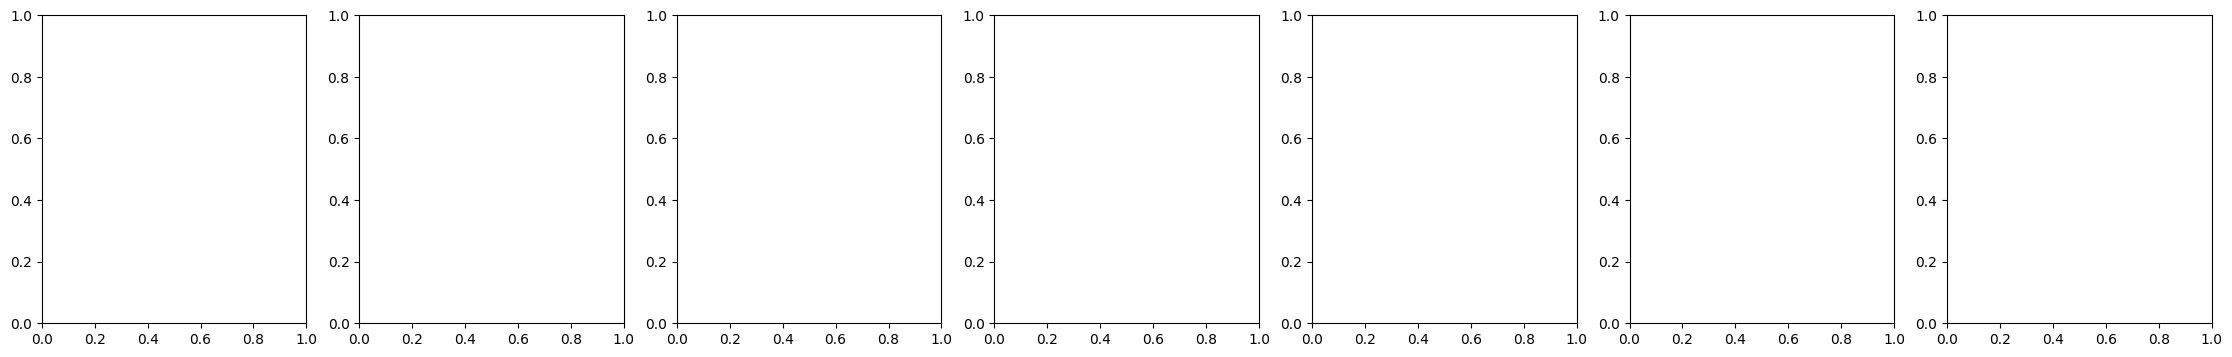

In [21]:
Modelos = {
    "KNN": grid_knn,
    "Regresión Logística": grid_rl,
    "Decision Tree": grid_dt,
    "Random Forest": grid_rf,
    "Gradient Boosting": grid_gb,
    "Voting Hard": voting_model_hard,
    "Voting Soft": voting_model_soft}

df_comparativa = evaluate_models(Modelos, X_test, y_test, target_names)
display(df_comparativa)